In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn

In [ ]:
data_dir = './data'
imputated_data_path = f'{data_dir}/2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
print("Loading {imputated_data_path}")
data = pd.read_csv(imputated_data_path) # reload imputed data to get all rows, but now with missing values filled in

Loading {imputated_data_path}


FileNotFoundError: [Errno 2] No such file or directory: './data/2025_LoL_esports_match_data_from_OraclesElixir_imputated'

In [ ]:
data

,Unnamed: 0,gameid,datacompleteness,url,league,year,split,playoffs,date,game,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,0,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,...,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,1,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,...,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,2,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,...,241.0,-1552.0,-2465.0,-41.0,1.0,0.0,2.0,1.0,5.0,1.0
3,3,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,...,257.0,-2613.0,-1156.0,-6.0,1.0,1.0,2.0,6.0,2.0,0.0
4,4,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,...,20.0,-662.0,-734.0,18.0,0.0,2.0,2.0,0.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120631,120631,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,...,224.0,-125.0,-500.0,-32.0,8.0,5.0,2.0,4.0,4.0,1.0
120632,120632,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,...,221.0,-541.0,513.0,5.0,0.0,7.0,2.0,2.0,4.0,2.0
120633,120633,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,...,31.0,1255.0,2399.0,17.0,1.0,9.0,1.0,1.0,1.0,4.0
120634,120634,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,...,874.0,-4102.0,-8294.0,-66.0,8.0,18.0,13.0,13.0,34.0,8.0


In [ ]:
from utils.constants import most_relevant_columns, pos_order
from utils.transform import champion_class_transform

In [ ]:
# Group by game id, and then for each team, join the rows together, so that we have one row per team per game, with all the stats for that team in that game. Keep the kills deaths and assists. Make sure to join the team members in the other of position (top, jgl, mid, bot, sup). Append the colums, so you get one big row per team.
df = data.copy()
# Remove position "team"
df = df[df['position'] != 'team']
df['position'] = pd.Categorical(df['position'], categories=pos_order, ordered=True)
champion_class_transform(df)

df = df.sort_values(by=['gameid', 'teamname', 'position'])
#selected_columns = ['kills', 'deaths', 'assists']
selected_columns = most_relevant_columns
selected_columns = [col for col in selected_columns if col != 'champion']
team_df = df.pivot(index=['gameid', 'teamname', 'gamelength'], columns='position', values=selected_columns)

team_df.columns = [f'{val}_{pos}' for val, pos in team_df.columns]

team_df = team_df.reset_index()

results = data[data['position'] == 'team'][['gameid', 'teamname', 'result']]
team_df = team_df.merge(results, on=['gameid', 'teamname'])
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
0,11715-11715_game_1,Oh My God,2123,1.0,2.0,0.0,2.0,0.0,2.0,4.0,...,NaN,NaN,NaN,NaN,2123.0,2123.0,2123.0,2123.0,2123.0,0
1,11715-11715_game_1,Weibo Gaming,2123,4.0,4.0,5.0,3.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,2123.0,2123.0,2123.0,2123.0,2123.0,1
2,11715-11715_game_2,Oh My God,1952,6.0,1.0,4.0,0.0,0.0,1.0,6.0,...,NaN,NaN,NaN,NaN,1952.0,1952.0,1952.0,1952.0,1952.0,0
3,11715-11715_game_2,Weibo Gaming,1952,5.0,6.0,1.0,4.0,2.0,3.0,2.0,...,NaN,NaN,NaN,NaN,1952.0,1952.0,1952.0,1952.0,1952.0,1
4,11715-11715_game_3,Oh My God,2014,1.0,6.0,6.0,5.0,0.0,4.0,6.0,...,NaN,NaN,NaN,NaN,2014.0,2014.0,2014.0,2014.0,2014.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,8253.0,9899.0,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,9398.0,12404.0,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,8313.0,9433.0,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,8704.0,8827.0,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0


In [ ]:
duplicate_mask = df.duplicated(subset=['gameid', 'teamname', 'position'], keep=False)
problem_rows = df[duplicate_mask].sort_values(['gameid', 'teamname', 'position'])
print(f"Found {len(problem_rows)}/{len(df)} duplicate rows.")

Found 0/100530 duplicate rows.


Text(0.5, 1.0, 'percentage of missing values by column')

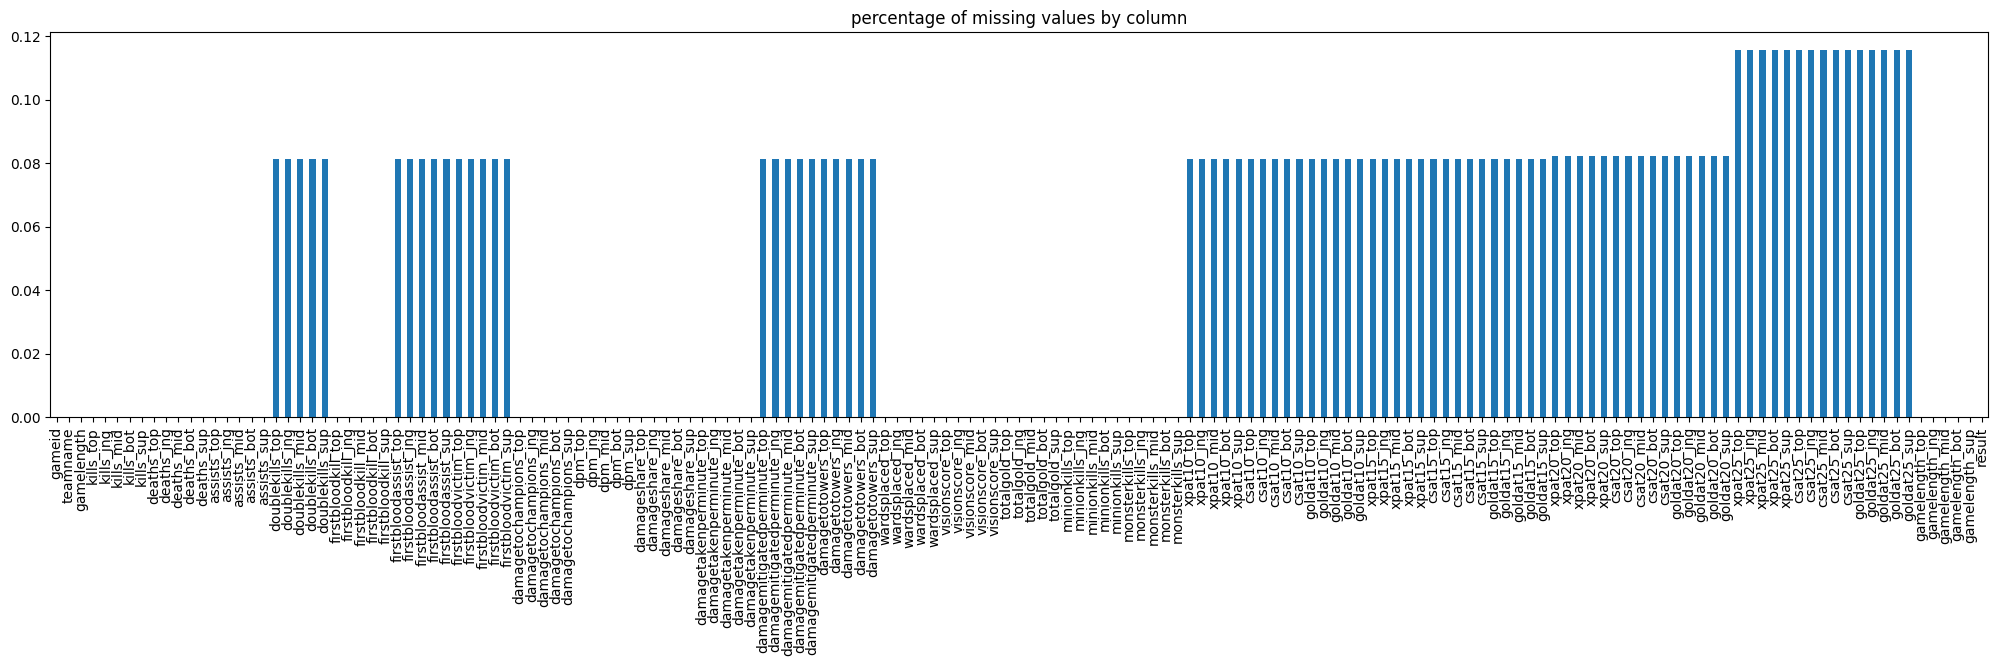

In [ ]:
team_df.isnull().mean().plot(kind='bar', figsize=(25, 5))
plt.title('percentage of missing values by column')

Remaining data: 17784/20106


<Axes: >

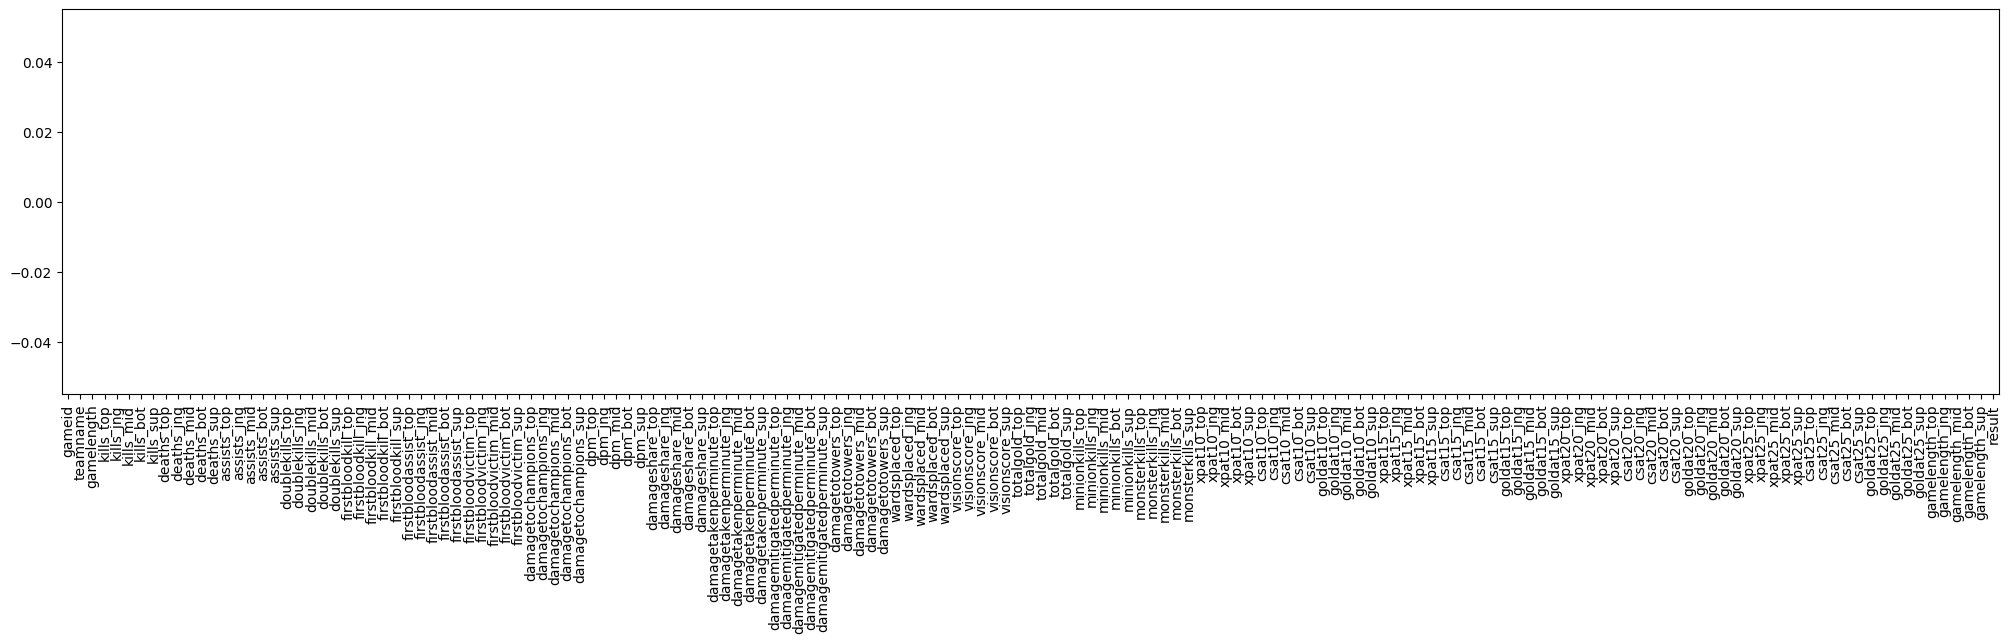

In [ ]:
from utils.transform import smart_drop_na

full_length = len(team_df)
team_df = smart_drop_na(team_df)

# Remaining data:
print(f"Remaining data: {len(team_df)}/{full_length}")
team_df.isnull().mean().plot(kind='bar', figsize=(25, 5))

In [ ]:
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
1634,LOLTMNT01_189225,Chiefs Esports Club,1522,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,7595.0,8034.0,8645.0,5262.0,1522.0,1522.0,1522.0,1522.0,1522.0,0
1635,LOLTMNT01_189225,PSG Talon,1522,1.0,4.0,6.0,2.0,0.0,0.0,0.0,...,9974.0,11030.0,10678.0,6579.0,1522.0,1522.0,1522.0,1522.0,1522.0,1
1636,LOLTMNT01_189281,GAM Esports,2266,1.0,4.0,1.0,0.0,1.0,5.0,3.0,...,10167.0,8507.0,9006.0,6325.0,2266.0,2266.0,2266.0,2266.0,2266.0,0
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,2.0,2.0,3.0,9.0,2.0,2.0,2.0,...,8301.0,8872.0,11944.0,6137.0,2266.0,2266.0,2266.0,2266.0,2266.0,1
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,1.0,4.0,1.0,6.0,0.0,0.0,3.0,...,9327.0,8294.0,11085.0,6016.0,1565.0,1565.0,1565.0,1565.0,1565.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,8253.0,9899.0,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,9398.0,12404.0,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,8313.0,9433.0,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,8704.0,8827.0,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0


In [ ]:
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(team_df.drop(columns=['gameid', 'teamname', "result"]))

kmeans = KMeans(n_clusters=4, n_init=10)
team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

Detected 178 unusual games.


In [ ]:
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result,cluster_label,is_outlier
1634,LOLTMNT01_189225,Chiefs Esports Club,1522,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,8645.0,5262.0,1522.0,1522.0,1522.0,1522.0,1522.0,0,0,1
1635,LOLTMNT01_189225,PSG Talon,1522,1.0,4.0,6.0,2.0,0.0,0.0,0.0,...,10678.0,6579.0,1522.0,1522.0,1522.0,1522.0,1522.0,1,2,1
1636,LOLTMNT01_189281,GAM Esports,2266,1.0,4.0,1.0,0.0,1.0,5.0,3.0,...,9006.0,6325.0,2266.0,2266.0,2266.0,2266.0,2266.0,0,1,1
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,2.0,2.0,3.0,9.0,2.0,2.0,2.0,...,11944.0,6137.0,2266.0,2266.0,2266.0,2266.0,2266.0,1,3,1
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,1.0,4.0,1.0,6.0,0.0,0.0,3.0,...,11085.0,6016.0,1565.0,1565.0,1565.0,1565.0,1565.0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0,0,1
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1,1,1
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0,0,1
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0,0,1


In [ ]:
from utils.visualize import cluster_summary

In [ ]:
cluster_sum = cluster_summary(team_df) 
cluster_sum

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,csat10_bot,csat10_jng,csat10_mid,csat10_sup,csat10_top,...,xpat20_bot,xpat20_jng,xpat20_mid,xpat20_sup,xpat20_top,xpat25_bot,xpat25_jng,xpat25_mid,xpat25_sup,xpat25_top
cluster_label,,,,,,,,,,,,,,,,,,,,,
0,0.503758,0.505544,0.475707,0.495835,0.453689,0.970560,0.964937,0.970162,1.000298,0.963953,...,0.958336,0.945725,0.964995,0.982775,0.967107,0.932939,0.916444,0.943665,0.952256,0.942330
1,0.914779,0.938322,0.925417,0.908036,0.927558,1.022950,1.020504,1.030252,1.026907,1.030377,...,1.003229,0.995850,1.011132,0.968485,1.010322,0.999811,0.988080,1.007644,0.953015,1.008504
2,1.410796,1.379853,1.416904,1.445942,1.392134,1.006854,1.016211,1.000004,0.959316,1.010835,...,1.045371,1.070032,1.030866,1.064390,1.030264,1.079937,1.115780,1.061201,1.123667,1.062681
3,1.407967,1.412048,1.430854,1.379347,1.505567,1.002901,1.002776,1.001620,1.016098,0.995806,...,0.999328,0.996612,0.996124,0.985689,0.994637,0.997509,0.991983,0.993636,0.975606,0.992264


In [ ]:
# For each cluster, calculate the win rate
win_rates = team_df.groupby('cluster_label')['result'].mean()
win_rates

cluster_label
0    0.017607
1    0.532753
2    0.957874
3    0.605146
Name: result, dtype: float64

In [ ]:
losing_team_df = team_df[team_df['result'] == 0]
winning_team_df = team_df[team_df['result'] == 1]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(winning_team_df.drop(columns=['gameid', 'teamname', "result"]))

kmeans = KMeans(n_clusters=4, n_init=10)
winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

cluster_sum_winning = cluster_summary(winning_team_df)
cluster_sum_winning.filter(regex='^(totalgold)_')

C:\Users\vlad\AppData\Local\Temp\ipykernel_13580\3163696615.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)


,totalgold_bot,totalgold_jng,totalgold_mid,totalgold_sup,totalgold_top
cluster_label,,,,,
0,0.997563,0.955967,0.960086,1.002873,0.933431
1,0.971376,0.958783,0.988500,0.960800,1.005880
2,1.251319,1.197784,1.225442,1.205319,1.215104
3,0.872547,0.953567,0.896647,0.911325,0.902260


In [ ]:
cluster_sum_winning.filter(regex='^(gamelength)')

,gamelength,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top
cluster_label,,,,,,
0,0.963080,0.963080,0.963080,0.963080,0.963080,0.963080
1,0.994195,0.994195,0.994195,0.994195,0.994195,0.994195
2,1.261730,1.261730,1.261730,1.261730,1.261730,1.261730
3,0.863905,0.863905,0.863905,0.863905,0.863905,0.863905


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(winning_team_df.drop(columns=['gameid', 'teamname', "result"]))
iso = IsolationForest(contamination=0.01)
winning_team_df['is_outlier'] = iso.fit_predict(scaled_data)
outliers = winning_team_df[winning_team_df['is_outlier'] == -1]
print(f"Detected {len(outliers)} unusual games.")

Detected 89 unusual games.


C:\Users\vlad\AppData\Local\Temp\ipykernel_13580\406403066.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['is_outlier'] = iso.fit_predict(scaled_data)


In [ ]:
from utils.visualize import plot_outlier_distribution

plot_outlier_distribution(winning_team_df, 'kills_sup', title_suffix="(Support)")
plot_outlier_distribution(winning_team_df, 'kills_mid', title_suffix="(Mid Lane)")

ImportError: cannot import name 'plot_outlier_distribution' from 'utils.visualize' (c:\Users\vlad\Documents\uni\au\data_mining\datamining_project\utils\visualize.py)

### Example of learning bias for kills_mid against the gamelength

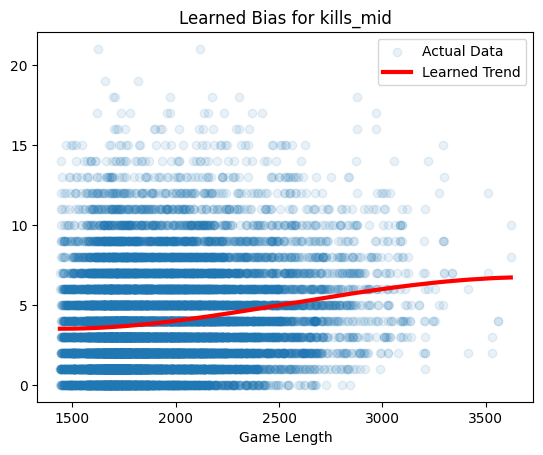

In [ ]:
from utils.transform import simple_scale_model
# 1. Setup the model: Splines + Ridge Regression
# 'n_knots' determines how "wiggly" the curve can be. 5-10 is usually plenty.

target_col = 'kills_mid' 
X = team_df[['gamelength']].sort_values(by='gamelength')
y = team_df.loc[X.index, target_col]

simple_scale_model.fit(X, y)
curve = simple_scale_model.predict(X)

plt.scatter(X, y, alpha=0.1, label='Actual Data')
plt.plot(X, curve, color='red', linewidth=3, label='Learned Trend')
plt.title(f'Learned Bias for {target_col}')
plt.xlabel('Game Length')
plt.legend()
plt.show()

In [ ]:
from utils.transform import scale_df
lengthscaled_winning_team_df = scale_df(winning_team_df.drop(columns=['cluster_label', 'is_outlier']))

c:\Users\vlad\Documents\uni\au\data_mining\datamining_project\utils\transform.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_residuals[col] = df[col] - model.predict(df[['gamelength']])
c:\Users\vlad\Documents\uni\au\data_mining\datamining_project\utils\transform.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_residuals[col] = df[col] - model.predict(df[['gamelength']])
c:\Users\vlad\Documents\uni\au\data_mining\datamining_project\utils\transform.py:85: PerformanceWarning: DataFrame is highly fragmented.  This i

In [ ]:
lengthscaled_winning_team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
1635,LOLTMNT01_189225,PSG Talon,1522,-3.331673,-1.239890,0.607745,-4.843468,-1.261461,-1.513722,-1.254015,...,-437.469236,-73.076281,-1065.087986,-351.589086,1522.0,1522.0,1522.0,1522.0,1522.0,1
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,-2.262855,-2.184300,-2.388630,1.779860,0.946525,-0.906902,-0.906211,...,-593.449288,-771.534995,1875.086256,209.478396,2266.0,2266.0,2266.0,2266.0,2266.0,1
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,-3.285924,-1.111040,-4.349314,-0.768951,-1.230827,-1.554207,1.677290,...,-919.882570,-2656.183281,-466.393034,-795.318200,1565.0,1565.0,1565.0,1565.0,1565.0,1
1642,LOLTMNT01_189329,Gamespace Mediterranean College Esports,1779,-1.143838,-2.606382,0.779466,-2.626189,-0.120376,0.143502,0.264716,...,-659.661246,-176.576026,904.957336,651.200000,1779.0,1779.0,1779.0,1779.0,1779.0,1
1644,LOLTMNT01_189338,Actions Per Minute,2123,-3.173781,-1.216703,-2.279952,3.032955,-0.054785,-0.574684,2.448697,...,-557.714869,-932.328240,232.714004,-448.910117,2123.0,2123.0,2123.0,2123.0,2123.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20097,LOLTMNT06_96870,Karmine Corp Blue Stars,2792,-0.850474,-0.546867,-2.111958,6.944303,-1.079436,0.050344,-1.013317,...,-1288.161345,-31.028236,-904.726679,-345.322459,2792.0,2792.0,2792.0,2792.0,2792.0,1
20098,LOLTMNT06_96906,IziDream,2169,-0.198134,-4.198810,0.690017,0.955272,-1.053223,0.318802,-0.665881,...,-1423.859831,716.045199,4.884127,384.048985,2169.0,2169.0,2169.0,2169.0,2169.0,1
20100,LOLTMNT06_96972,BK ROG Esports,1847,4.873648,-1.490668,-2.207605,-0.648158,-1.098054,2.018759,2.114042,...,-1401.553432,-1373.045233,613.857655,-157.225273,1847.0,1847.0,1847.0,1847.0,1847.0,1
20102,LOLTMNT06_96989,BK ROG Esports,1954,-4.123297,-3.348698,1.787299,0.265775,-0.073215,-1.197992,0.863767,...,163.207507,2419.139600,212.158502,-100.482291,1954.0,1954.0,1954.0,1954.0,1954.0,1


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(lengthscaled_winning_team_df.drop(columns=['gameid', 'teamname', "result", "gamelength"]))

kmeans = KMeans(n_clusters=2, n_init=10)
winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

C:\Users\vlad\AppData\Local\Temp\ipykernel_13580\1470355347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)


In [ ]:
prof_sum_winning = cluster_summary(winning_team_df, cluster_col='cluster_label')
#prof_sum_winning.filter(regex='^(totalgold)_')
prof_sum_winning.filter(regex='^(kills)_')

,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,
0,0.855833,0.786944,0.885768,0.745614,0.947157
1,1.198596,1.293493,1.157359,1.350427,1.072794


In [ ]:
prof_sum_winning.filter(regex='^(gamelength)$')

,gamelength
cluster_label,
0,1.001074
1,0.998520


In [ ]:
# Number of games in each cluster
winning_team_df['cluster_label'].value_counts()

cluster_label
0    5152
1    3740
Name: count, dtype: int64

In [ ]:
df_team_profiles = winning_team_df.drop(columns=['gameid'])
df_team_profiles = df_team_profiles.groupby('teamname').mean().reset_index()
df_team_profiles

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_team_profiles.drop(columns=['teamname', "result", "gamelength", "cluster_label"]))

kmeans = KMeans(n_clusters=4, n_init=10)
df_team_profiles['cluster_label'] = kmeans.fit_predict(scaled_data)
cluster_summary(df_team_profiles, cluster_col='cluster_label').filter(regex='^(kills|deaths|assists|gamelength)_')

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,deaths_bot,deaths_jng,deaths_mid,deaths_sup,deaths_top,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,,,,,,,,,,,,,,,,
0,0.950002,0.937950,0.952721,0.931385,0.943551,0.812820,0.881856,0.835143,0.874731,0.825093,1.015808,1.015808,1.015808,1.015808,1.015808,0.892097,0.902190,0.911513,0.817963,0.934549
1,1.149148,1.170360,1.160442,1.190469,1.279978,1.557217,1.512344,1.556446,1.338108,1.455653,1.168553,1.168553,1.168553,1.168553,1.168553,1.372421,1.087759,1.115379,1.086717,1.047488
2,1.078973,0.996916,1.068121,1.059009,1.014531,1.051083,0.928401,0.991942,1.037809,1.040011,0.931252,0.931252,0.931252,0.931252,0.931252,1.043676,1.316219,1.025959,1.186933,1.008719
3,0.974705,1.034788,0.974891,0.999495,0.987326,1.056119,1.056074,1.064388,1.044699,1.074700,0.976863,0.976863,0.976863,0.976863,0.976863,1.009809,0.905920,1.065272,1.092665,1.064921


In [ ]:
df_team_profiles['cluster_label'].value_counts()

cluster_label
0    165
3    130
2     80
1     35
Name: count, dtype: int64

In [ ]:
df_team_profiles = lengthscaled_winning_team_df.drop(columns=['gameid'])
df_team_profiles = df_team_profiles.groupby('teamname').mean().reset_index()
df_team_profiles

,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,deaths_mid,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
0,100 Thieves,2043.634146,-0.402599,-0.352557,0.468055,-0.610244,-0.178746,0.097721,0.102546,-0.358760,...,-124.763305,166.901989,-198.433973,-170.818076,2043.634146,2043.634146,2043.634146,2043.634146,2043.634146,1.0
1,3BL Esports,1922.000000,1.878804,-0.386180,2.791995,-1.702556,-0.079428,-0.130902,-2.059974,5.062371,...,-69.822838,191.020380,-1545.478409,-662.907296,1922.000000,1922.000000,1922.000000,1922.000000,1922.000000,1.0
2,5M Esports,2421.000000,-1.399840,1.779060,-1.554421,3.489659,0.939637,-0.258597,-0.277159,3.054426,...,742.424800,-885.025586,255.338082,-79.055349,2421.000000,2421.000000,2421.000000,2421.000000,2421.000000,1.0
3,7REX,2225.600000,-0.331168,0.839841,-0.468668,0.615641,-0.873258,-0.992301,-1.372363,-1.736623,...,303.597727,144.974945,160.867817,14.186836,2225.600000,2225.600000,2225.600000,2225.600000,2225.600000,1.0
4,A One Man Army,1997.777778,-1.165241,0.763104,0.120515,-0.844462,0.016025,0.011675,0.193133,0.843450,...,910.779559,141.536006,-259.294491,192.377195,1997.777778,1997.777778,1997.777778,1997.777778,1997.777778,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,mCon esports,1982.190476,0.038050,1.305171,1.361439,-1.264574,0.060342,0.259427,-0.278198,-0.306424,...,281.245844,182.455941,-523.814534,-42.567860,1982.190476,1982.190476,1982.190476,1982.190476,1982.190476,1.0
406,paiN Gaming,2034.406250,-0.318470,-0.948943,-1.299246,-0.602444,-0.120494,-0.654311,-1.156242,-0.269119,...,-363.522985,-398.131324,-64.574171,-247.775754,2034.406250,2034.406250,2034.406250,2034.406250,2034.406250,1.0
407,regnum4games,1812.000000,-4.133786,1.452326,-2.212648,0.366647,1.891140,-1.915603,-0.807458,0.266196,...,220.953909,-1710.965025,1393.883594,-33.275798,1812.000000,1812.000000,1812.000000,1812.000000,1812.000000,1.0
408,wangting,1886.916667,1.996635,2.709969,1.364844,0.498569,0.544973,1.174027,0.654878,1.013515,...,966.260153,85.400541,198.288355,438.955661,1886.916667,1886.916667,1886.916667,1886.916667,1886.916667,1.0


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_team_profiles.drop(columns=['teamname', "result", "gamelength", "cluster_label"]))

kmeans = KMeans(n_clusters=4, n_init=10)
df_team_profiles['cluster_label'] = kmeans.fit_predict(scaled_data)
cluster_summary(df_team_profiles, cluster_col='cluster_label').filter(regex='^(kills|deaths|assists|gamelength)_')

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,deaths_bot,deaths_jng,deaths_mid,deaths_sup,deaths_top,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,,,,,,,,,,,,,,,,
0,-0.663031,-0.736652,-0.541678,-0.840432,-0.648057,-1.972640,-1.584702,-1.388452,-1.819006,-2.177626,1.006004,1.006004,1.006004,1.006004,1.006004,-1.293325,-1.276658,-0.686105,-0.896556,-0.692577
1,5.301373,2.853305,4.536271,3.420032,5.602696,6.081361,4.668109,8.696670,6.484750,7.334878,0.997462,0.997462,0.997462,0.997462,0.997462,2.696085,3.659039,1.180936,7.992276,16.935427
2,0.411328,2.648963,0.376125,1.514695,0.879523,2.151391,2.410044,1.275927,1.010332,2.123775,1.010042,1.010042,1.010042,1.010042,1.010042,3.065306,-1.830409,2.111701,2.119300,-0.295931
3,3.960046,1.914934,4.026743,3.530163,3.151769,4.187470,3.483071,3.091638,5.290024,4.212243,0.973200,0.973200,0.973200,0.973200,0.973200,2.653683,9.137549,3.196301,1.056858,0.570025


In [ ]:
df_team_profiles['cluster_label'].value_counts()

cluster_label
0    184
2    114
3     81
1     31
Name: count, dtype: int64